In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet('../data/processed/data.parquet')

In [3]:
df = df.sort_values(by=['eom', 'id'], ascending = True)

In [4]:
df

,id,date,eom,source_crsp,size_grp,obs_main,exch_main,primary_sec,gvkey,iid,...,rvol_252d,zero_trades_252d,corr_1260d,betabab_1260d,rmax5_rvol_21d,age,qmj,qmj_prof,qmj_growth,qmj_safety
58203,100100401,1981-01-31,1981-01-31,0,mega,1,1,1,1004.0,1.0,...,NaN,NaN,NaN,NaN,NaN,181,NaN,NaN,NaN,NaN
58731,100100501,1981-01-31,1981-01-31,0,mega,1,1,1,1005.0,1.0,...,NaN,NaN,NaN,NaN,NaN,97,NaN,NaN,NaN,NaN
58765,100101301,1981-01-31,1981-01-31,0,mega,1,1,1,1013.0,1.0,...,NaN,NaN,NaN,NaN,NaN,85,NaN,NaN,NaN,NaN
59125,100101601,1981-01-31,1981-01-31,0,mega,1,1,1,1016.0,1.0,...,NaN,NaN,NaN,NaN,NaN,85,NaN,NaN,NaN,NaN
59160,100101701,1981-01-31,1981-01-31,0,mega,1,1,1,1017.0,1.0,...,NaN,NaN,NaN,NaN,NaN,253,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2332866,135625701,2025-12-31,2025-12-31,0,mega,1,1,1,356257.0,1.0,...,NaN,NaN,NaN,NaN,NaN,152,NaN,NaN,NaN,NaN
2332889,135628901,2025-12-31,2025-12-31,0,mega,1,1,1,356289.0,1.0,...,NaN,NaN,NaN,NaN,NaN,60,NaN,NaN,NaN,NaN
2332902,135685901,2025-12-31,2025-12-31,0,mega,1,1,1,356859.0,1.0,...,NaN,NaN,NaN,NaN,NaN,36,NaN,NaN,NaN,NaN
2332909,136691101,2025-12-31,2025-12-31,0,mega,1,1,1,366911.0,1.0,...,NaN,NaN,NaN,NaN,NaN,48,NaN,NaN,NaN,NaN


In [5]:
for col in df.columns.to_list():
    print(col)

id
date
eom
source_crsp
size_grp
obs_main
exch_main
primary_sec
gvkey
iid
permno
permco
excntry
curcd
fx
common
comp_tpci
crsp_shrcd
comp_exchg
crsp_exchcd
adjfct
shares
me_lag1
gics
sic
naics
ff49
me_company
prc
prc_local
dolvol
ret
ret_lag_dif
ret_exc_lead1m
enterprise_value
book_equity
assets
sales
net_income
bidask
prc_high
prc_low
tvol
div1m_me
div3m_me
div6m_me
div12m_me
divspc1m_me
divspc12m_me
chcsho_1m
chcsho_3m
chcsho_6m
chcsho_12m
eqnpo_1m
eqnpo_3m
eqnpo_6m
eqnpo_12m
ret_1_0
ret_2_0
ret_3_0
ret_3_1
ret_6_0
ret_6_1
ret_9_0
ret_9_1
ret_12_0
ret_12_1
ret_12_7
ret_18_1
ret_24_1
ret_24_12
ret_36_1
ret_36_12
ret_48_12
ret_48_1
ret_60_1
ret_60_12
ret_60_36
seas_1_1an
seas_1_1na
seas_2_5an
seas_2_5na
seas_6_10an
seas_6_10na
seas_11_15an
seas_11_15na
seas_16_20an
seas_16_20na
at_gr1
ca_gr1
nca_gr1
lt_gr1
cl_gr1
ncl_gr1
be_gr1
pstk_gr1
debt_gr1
sale_gr1
cogs_gr1
sga_gr1
opex_gr1
capx_gr1
inv_gr1
at_gr3
ca_gr3
nca_gr3
lt_gr3
cl_gr3
ncl_gr3
be_gr3
pstk_gr3
debt_gr3
sale_gr3
cogs_gr3
sga

In [6]:
len(df.columns)

438

In [7]:
# rets_df = pd.read_csv('../data/backtest/lasso/monthly_returns.csv')

In [8]:
# rets_df[['long_ret', 'short_ret']].cumsum().plot()

In [9]:
# rets = rets_df['long_ret'] - rets_df['short_ret']
# np.where(rets == rets.min())[0]

In [10]:
# rets_df.iloc[341]

In [11]:
port = pd.read_csv('../data/backtest/lasso/portfolios.csv')
port

,id,leg,weight,predicted_ret,realized_ret,eom
0,100518401,long,0.003344,-0.065307,0.038825,1990-01-31
1,100556801,long,0.003344,-0.065307,-0.030714,1990-01-31
2,100684801,long,0.003344,-0.065307,0.099772,1990-01-31
3,100688901,long,0.003344,-0.065307,-0.062961,1990-01-31
4,100680201,long,0.003344,-0.065307,-0.050968,1990-01-31
...,...,...,...,...,...,...
298243,104568302,short,-0.003922,-0.020661,-0.001521,2025-10-31
298244,106402801,short,-0.003922,-0.020661,-0.074828,2025-10-31
298245,106560501,short,-0.003922,-0.020661,-0.010143,2025-10-31
298246,105079802,short,-0.003922,-0.020661,-0.003477,2025-10-31


In [12]:
# port[(port['eom'] == '2018-06-30' and port['leg'] == 'short')]
temp = port[(port['eom'] == '2018-06-30') & (port['leg'] == 'short')]

In [13]:
temp

,id,leg,weight,predicted_ret,realized_ret,eom
251115,100851201,short,-0.003344,0.001145,0.040295,2018-06-30
251116,101388801,short,-0.003344,0.002328,0.013367,2018-06-30
251117,102976001,short,-0.003344,0.002832,0.015699,2018-06-30
251118,100816901,short,-0.003344,-0.000287,0.037924,2018-06-30
251119,117981702,short,-0.003344,-0.021071,-0.042459,2018-06-30
...,...,...,...,...,...,...
251409,102601201,short,-0.003344,-0.002724,-0.325015,2018-06-30
251410,103100401,short,-0.003344,-0.001919,-0.019886,2018-06-30
251411,102490102,short,-0.003344,-0.089647,-0.055627,2018-06-30
251412,101056502,short,-0.003344,-0.032871,0.185099,2018-06-30


In [14]:
ticker_116646001 = df[df['id'] == 116646001]
ticker_116646001 = ticker_116646001[['eom', 'ret']]

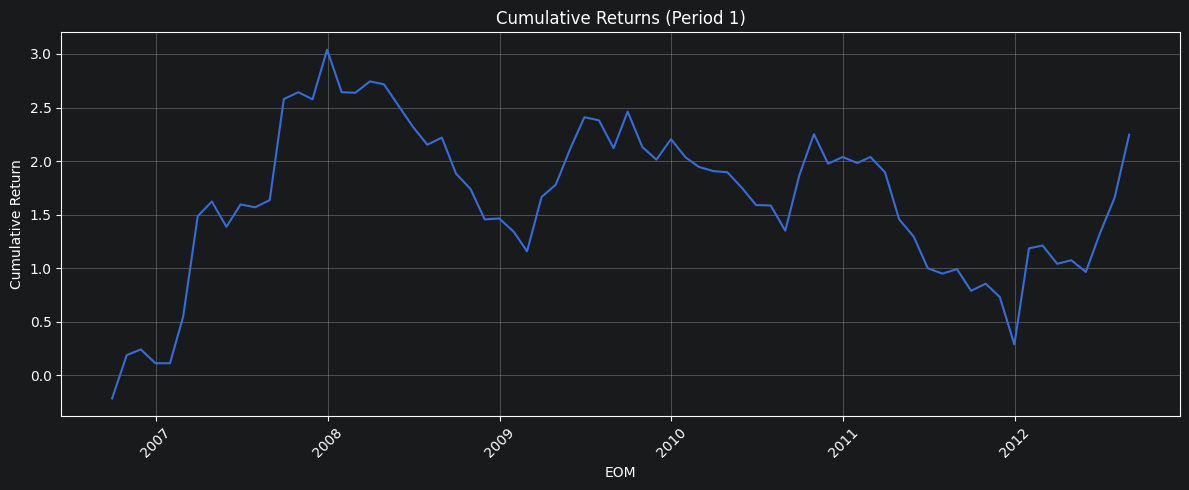

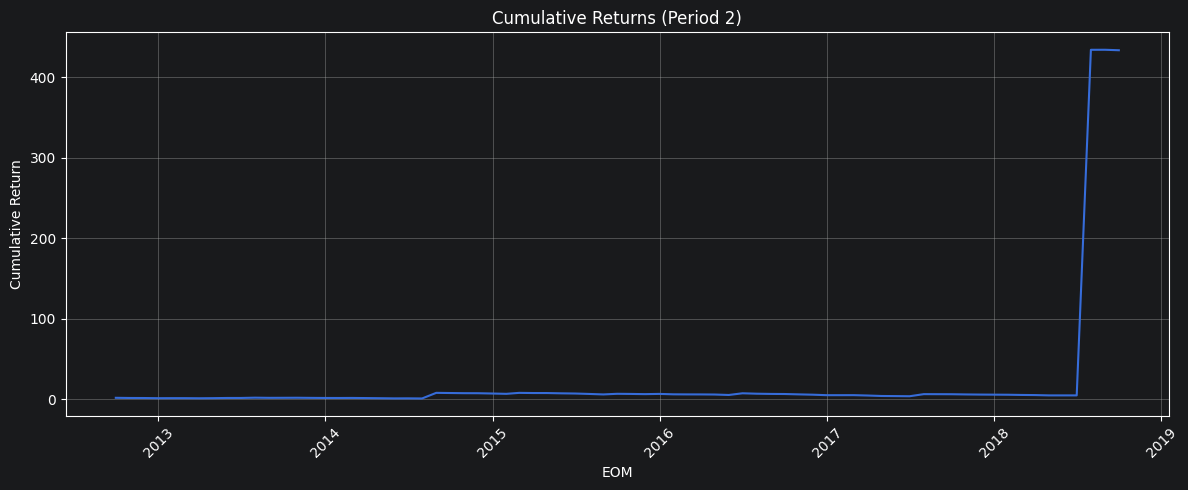

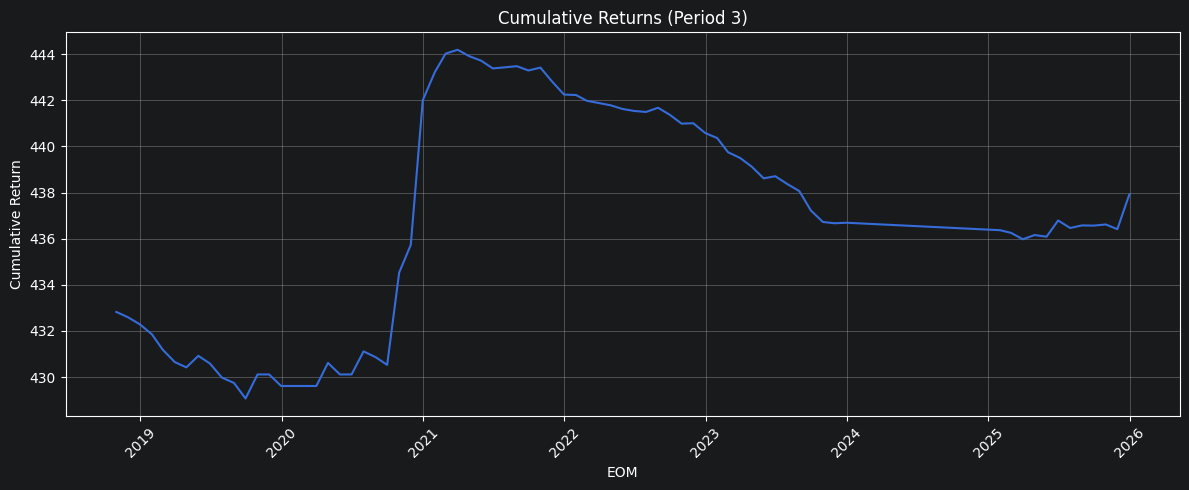

In [16]:
# Make sure eom is datetime
ticker_116646001['eom'] = pd.to_datetime(ticker_116646001['eom'])

# Sort by date
df = ticker_116646001.sort_values('eom').copy()

# Cumulative return
df['cum_ret'] = df['ret'].cumsum()

# Split into 3 equal chunks
n = len(df)
chunk_size = n // 3

chunks = [
    df.iloc[:chunk_size],
    df.iloc[chunk_size:2 * chunk_size],
    df.iloc[2 * chunk_size:]
]

for i, chunk in enumerate(chunks, 1):
    plt.figure(figsize=(12, 5))
    plt.plot(chunk['eom'], chunk['cum_ret'])
    plt.xlabel('EOM')
    plt.ylabel('Cumulative Return')
    plt.title(f'Cumulative Returns (Period {i})')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [33]:
cum_ret = ticker_116646001['ret'].cumsum()

max_idx = cum_ret.idxmax()
max_return = cum_ret.loc[max_idx]
max_date = ticker_116646001.loc[max_idx, 'eom']

print(max_return)
print(max_date)

444.18890594820016
2021-03-31 00:00:00


In [34]:
cum_ret

2189001           NaN
2189002     -0.218479
2189003      0.185966
2189004      0.239763
2189005      0.110634
              ...    
2189217    436.574441
2189218    436.564340
2189219    436.615361
2189220    436.411477
2189221    437.917575
Name: ret, Length: 221, dtype: float64

In [ ]:
# there is a stock that I shorted on that day which generated a return of over 400 (not 400%). This is what caused the sharp spike in the cumulative return.

In [36]:
ret_2018 = ticker_116646001.loc[
    ticker_116646001['eom'].dt.year == 2018,
    'ret'
]
ret_2018

2189138     -0.111111
2189139     -0.250000
2189140     -0.166667
2189141     -0.400000
2189142      0.000000
2189143      0.000000
2189144    429.000000
2189145      0.040310
2189146     -0.590164
2189147     -0.494545
2189148     -0.230216
2189149     -0.308411
Name: ret, dtype: float64